In [102]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
import torchinfo
import matplotlib.pyplot as plt

In [103]:
torch.manual_seed(42)

In [104]:
df = pd.read_csv("data/fmnist_small.csv")
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,9,0,0,0,0,0,0,0,0,0,...,0,7,0,50,205,196,213,165,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,...,142,142,142,21,0,3,0,0,0,0
3,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,8,0,0,0,0,0,0,0,0,0,...,213,203,174,151,188,10,0,0,0,0


Images display from CSV

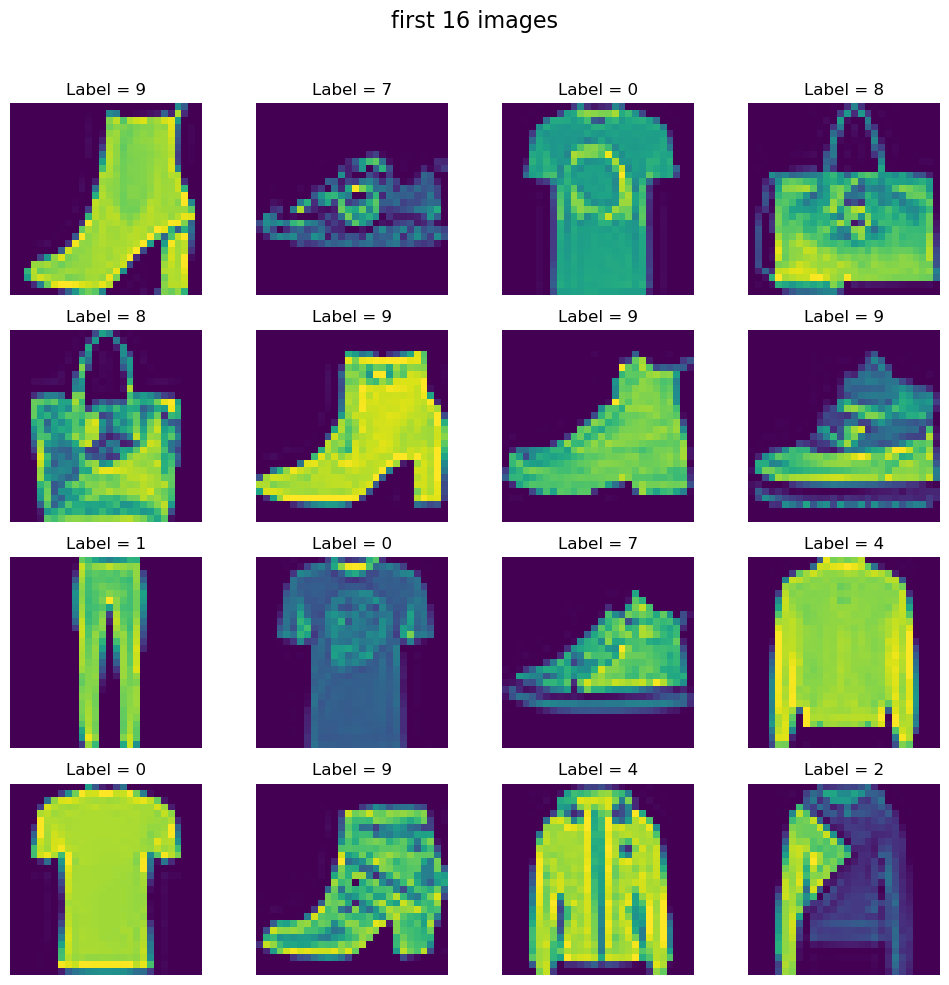

In [105]:
fig, axes = plt.subplots(4,4, figsize = (10,10))
fig.suptitle("first 16 images", fontsize = 16)

for i, ax in enumerate(axes.flat):
    img = df.iloc[i, 1: ].values.reshape(28,28)
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(f"Label = {df.iloc[i, 0]}")
    
plt.tight_layout(rect=[0,0,1,0.96])
plt.show()

In [106]:
X, y = df.iloc[:, 1:].values , df.iloc[:, 0].values

In [107]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 42)

In [108]:
X_train.shape

(4800, 784)

In [109]:
X_test.shape

(1200, 784)

In [110]:
#scaling features
X_train = X_train/255.0
X_test = X_test/255.0

Creating custom dataset

In [111]:
class CustomDataset(Dataset):
    
    def __init__(self, features, labels):
        self.features = torch.tensor(features, dtype= torch.float)
        self.labels = torch.tensor(labels, dtype= torch.long)
    
    def __len__(self):
        return len(self.features)
    
    def __getitem__(self, index):
        return self.features[index], self.labels[index]

Create dataset objects

In [112]:
train_data = CustomDataset(X_train, y_train)
test_data = CustomDataset(X_test, y_test)

In [113]:
train_dataloader = DataLoader(train_data, batch_size=32, shuffle= True)
test_dataloader = DataLoader(test_data, batch_size=32, shuffle= False)

Defining Model Class

In [114]:
class Model(nn.Module):
    
    def __init__(self, num_features):
        super().__init__()
        
        self.network = nn.Sequential(
            nn.Linear(num_features, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(p = 0.3),
            
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(p = 0.3),
            
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(p = 0.3),
            
            nn.Linear(64,10)
        )
        
        
    def forward(self, features):
        out = self.network(features)
        return out

Set params

In [115]:
epochs = 100
lr = 0.1

Model Instance

In [116]:
model = Model(X_train.shape[1])
model.train()

criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(model.parameters(), lr = lr, weight_decay=1e-4)

Training Loop

In [117]:
for epoch in range(epochs):
    
    total_epoch_loss = 0
    
    for batch_features, batch_labels in train_dataloader:
        
        y_pred = model(batch_features)
        
        loss = criterion(y_pred, batch_labels)
        
        total_epoch_loss += loss.item()
        
        optimizer.zero_grad()
        
        loss.backward()
        
        optimizer.step()
        
    num_batches = len(train_dataloader)
    print(f"Epoch = {epoch + 1}, loss = {total_epoch_loss/num_batches}")

Epoch = 1, loss = 1.0062350805600484
Epoch = 2, loss = 0.7196235464016596
Epoch = 3, loss = 0.6408534981807072
Epoch = 4, loss = 0.6127717853585879
Epoch = 5, loss = 0.549894002477328
Epoch = 6, loss = 0.5236872344215711
Epoch = 7, loss = 0.516223827501138
Epoch = 8, loss = 0.4962566136320432
Epoch = 9, loss = 0.4578016033768654
Epoch = 10, loss = 0.44895735949277876
Epoch = 11, loss = 0.43144980678955713
Epoch = 12, loss = 0.4106727111339569
Epoch = 13, loss = 0.395202007095019
Epoch = 14, loss = 0.3999880448977153
Epoch = 15, loss = 0.37561055878798166
Epoch = 16, loss = 0.3798185171186924
Epoch = 17, loss = 0.3567350334922473
Epoch = 18, loss = 0.3308659476538499
Epoch = 19, loss = 0.3388544713954131
Epoch = 20, loss = 0.3412458332876364
Epoch = 21, loss = 0.3257307457923889
Epoch = 22, loss = 0.3198051944375038
Epoch = 23, loss = 0.3055066541830699
Epoch = 24, loss = 0.2835861483961344
Epoch = 25, loss = 0.28575922603408493
Epoch = 26, loss = 0.28038270242512225
Epoch = 27, loss = 

In [118]:
torchinfo.summary(model)

Layer (type:depth-idx)                   Param #
Model                                    --
├─Sequential: 1-1                        --
│    └─Linear: 2-1                       200,960
│    └─BatchNorm1d: 2-2                  512
│    └─ReLU: 2-3                         --
│    └─Dropout: 2-4                      --
│    └─Linear: 2-5                       32,896
│    └─BatchNorm1d: 2-6                  256
│    └─ReLU: 2-7                         --
│    └─Dropout: 2-8                      --
│    └─Linear: 2-9                       8,256
│    └─BatchNorm1d: 2-10                 128
│    └─ReLU: 2-11                        --
│    └─Dropout: 2-12                     --
│    └─Linear: 2-13                      650
Total params: 243,658
Trainable params: 243,658
Non-trainable params: 0

Evaluation

In [119]:
model.eval()

Model(
  (network): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [120]:
total = 0
correct = 0

with torch.no_grad():
    
    for batch_features, batch_labels in test_dataloader:
        
        y_pred = model(batch_features)
        
        _, pred = torch.max(y_pred, 1)
        
        total += batch_labels.shape[0]
        
        correct = correct + (pred == batch_labels).sum().item()

print(correct/total)

0.8233333333333334


In [121]:
total = 0
correct = 0

with torch.no_grad():
    
    for batch_features, batch_labels in train_dataloader:
        
        y_pred = model(batch_features)
        
        _, pred = torch.max(y_pred, 1)
        
        total += batch_labels.shape[0]
        
        correct = correct + (pred == batch_labels).sum().item()

print(correct/total)

0.9891666666666666
